In [2]:
# -------------------------------------------------------------------------
# Programm berechnet die Schwingung einer kontinuierlichen Saite, die an
# einem Ende zu Schwingungen angeregt wird.
# -------------------------------------------------------------------------

# wichtige Bibliotheken importieren
import numpy as np
from matplotlib import pyplot as plt

In [3]:
#Parameter
#geometrische Parameter
L = 0.1                 # Länge der Seite in m
rho = 1150              # Massen(längen)dichte in kg/m
Phi = 3e9               # Elastizitäts(längen)modul

NG = 1001               # Gitterpunkte im Ort
dx = L/(NG-1)           # Abstand zweier Gitterpunkte
mNG = (NG+1)/2          # Mitte der Ortsachse

In [4]:
#Koordinaten für alle Gitterpunkte erstellen (1D-Array)
x = np.arange(NG)*dx    #Ortsgitter

In [6]:
#zeitliche Parameter
Tmax = 0.0001;          # maximale Zeit
NT = 100001;            # Schritte in der Zeit
dt = Tmax/(NT-1);       # Zeitschritt

In [7]:
#Zeit an allen Gitterpunkten bestimmen (1D-Array)
t = np.arange(NT)*dt    #Zeitgitter

In [8]:
#Gitter vorbereiten
y = np.zeros((NT,NG))

In [12]:
#Anregung/Anfangsbedinung
y[:,0] = np.sin(10*np.pi/Tmax*t)

In [13]:
#Lösen der DGL mit der Finite-Differenzen-Methode
for j in range(2,NT):
    for i in range(1, NG-1):
        yx2 = y[j-1,i-1]-2*y[j-1,i]+y[j-1,i+1]
        y[j,i] =2*y[j-1,i]-y[j-2,i]+Phi/rho * (dt/dx)**2 * yx2 

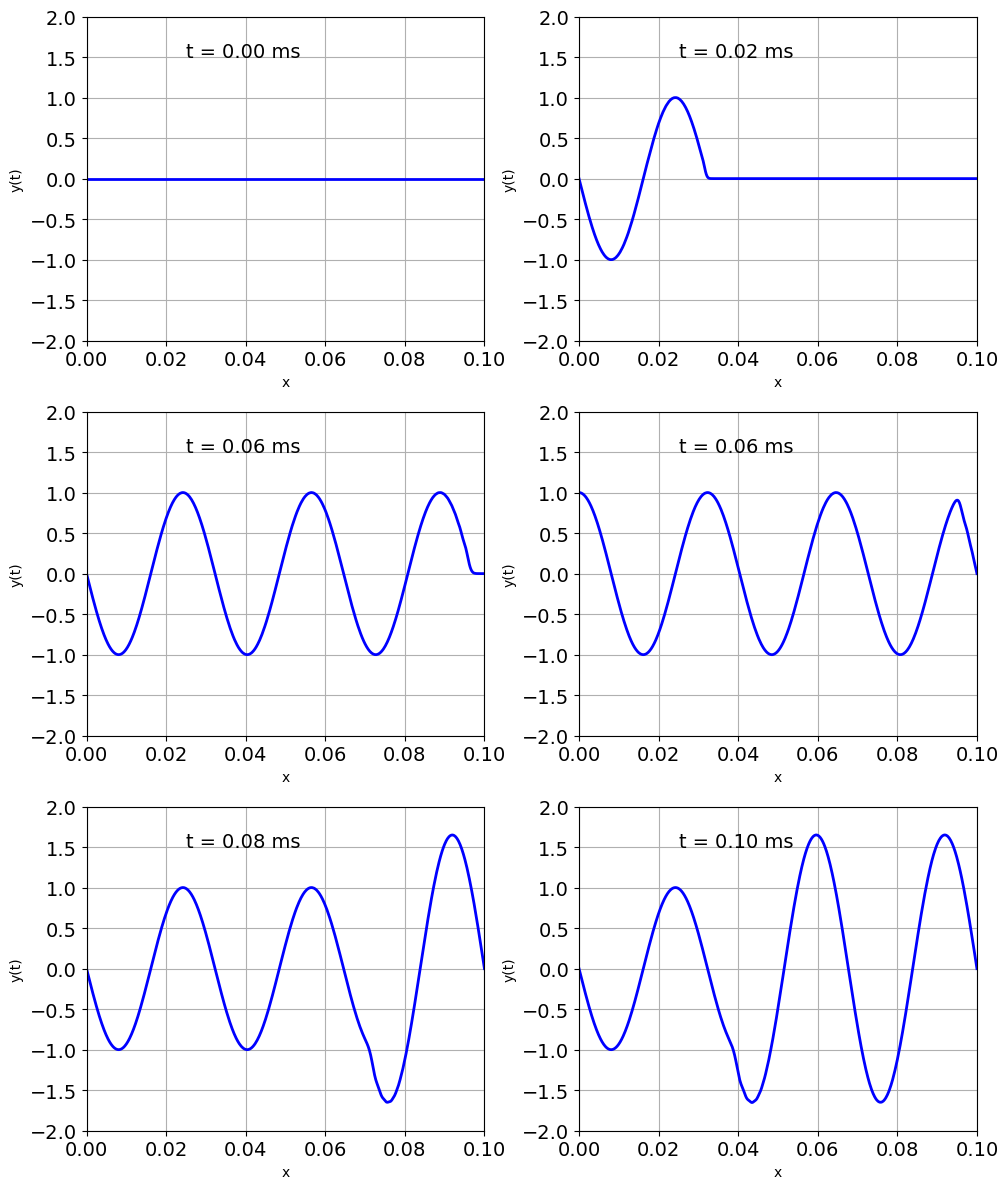

In [14]:
#Darstellung der Ergebnisse

#Zeitabschnitte wählen
k = [0, 19999, 59999, 64999, 79999, 100000]

#Unterfenster erzeugen (Subplots)
fig, axes = plt.subplots(3, 2, figsize=(10,12));

#Nummern und Index für jeweiliges Koordinatensystem erhalten
for idx, ax in enumerate(axes.flat):
    #Zeiten bei jeweiligen Fenstern
    j = k[idx]

    #Saiten zeichnen
    ax.plot(x, y[j, :], linewidth=2, color='blue')
    
    #optische Formatierungen
    ax.grid(True)
    ax.set_xlim([np.min(x), np.max(x)]) 
    ax.set_ylim([-2, 2])
    ax.set_xlabel("x")
    ax.set_ylabel("y(t)")
    titletext = "t = %.2f ms" % (t[j] * 1000) 
    ax.text(L/4, 1.5, titletext, fontsize=14)
    ax.tick_params(labelsize=14)

#Ausgabe
plt.tight_layout()
plt.show()